# Module 2d — DOCX, HTML & Markdown

- **Chapter 2, Module D of 14** — [chapter index](../README.md)
- **Prerequisites:** [2c — OCR & Scanned Documents](../2c.%20OCR%20and%20scanned%20documents/)
- **Next:** [2e — Structured Data (CSV, JSON, DB, API)](../2e.%20Structured%20data%20CSV%20JSON%20DB%20API/)

## The one idea

PDF has no real structure — every heading and paragraph break had to be *guessed back* from
coordinates in modules 2b and 2c. DOCX, HTML and Markdown are the opposite: the structure is
already there, tagged explicitly by the format itself. `<h1>` really means "heading level 1".
`Heading 2` really is a named style, not a bigger font we had to detect. The whole job of this
module is: **stop throwing that structure away.**

**By the end you will be able to:**

1. Explain why "structure already tagged" is fundamentally easier than "structure inferred"
2. Extract DOCX heading hierarchy and paragraph styles with `python-docx`
3. Parse real HTML with BeautifulSoup and strip boilerplate without losing content
4. Turn heading hierarchy into a "breadcrumb" that travels with every chunk
5. Compare all three formats side by side on the same underlying question

## Module roadmap

```mermaid
flowchart TD
    A["PDF (2b/2c)\nstructure INFERRED from pixels"] -.contrast.-> B["DOCX / HTML / Markdown\nstructure TAGGED by the format"]
    B --> C["python-docx:\nparagraph.style.name"]
    B --> D["BeautifulSoup:\nreal DOM tree"]
    C --> E["Heading hierarchy"]
    D --> E
    E --> F["Breadcrumb per chunk\n(what section is this from?)"]
    D --> G["Boilerplate removal\n(nav / footer / script)"]
    F --> H["Better retrieval:\nchunk carries its own context"]
    G --> H

## Why this module is a relief

```mermaid
flowchart LR
    subgraph PDF["PDF (2b, 2c)"]
        P1["Coordinates"] --> P2["Guess columns"]
        P2 --> P3["Guess headings\nfrom font size"]
        P3 --> P4["Guess reading order"]
    end
    subgraph DOCX_HTML["DOCX / HTML (this module)"]
        D1["Heading 2 style"] --> D2["IS a heading.\nNo guessing."]
        D3["<h2> tag"] --> D2
    end
```

Every guess in the PDF pipeline was a potential error we had to measure and defend (recall
%, false positives). Native-structure formats remove that whole category of error — the
remaining work is simpler: *read* the structure, don't *reconstruct* it.

## Setup

In [1]:
# `sys` lets us add the project root to Python's import path.
import sys

# The notebook sits two levels below the project root.
sys.path.append("../..")

# The corpus helper downloads real public documents and caches them locally.
from utils.corpus import fetch


# Define a small helper that reports whether an optional library is installed.
def try_import(module_name, friendly_name, install_hint):

    # Attempt the import; a missing package must not be fatal.
    try:
        module = __import__(module_name)

    # Report how to install it and return None.
    except ImportError:
        print(f"  [ ] {friendly_name:<20} missing  -  {install_hint}")
        return None

    # On success, report availability and hand back the module.
    print(f"  [x] {friendly_name:<20} available")
    return module


# Announce the dependency check.
print("Libraries:")

# python-docx reads .docx files - Word's real XML structure, not a text dump.
docx = try_import("docx", "python-docx", "pip install python-docx")

# BeautifulSoup parses HTML into a real, navigable tree.
bs4 = try_import("bs4", "beautifulsoup4", "pip install beautifulsoup4")

Libraries:
  [x] python-docx          available
  [x] beautifulsoup4       available


# 1. DOCX: reading Word's real structure

**The intuition before the code.** A `.docx` file is a zipped folder of XML files — you can
literally `unzip demo.docx` and read `word/document.xml`. Every paragraph in that XML already
carries a `style` name (`"Heading 1"`, `"Heading 2"`, `"Normal"`, `"List Bullet"`, ...). We are
not detecting a heading from font size like in module 2b/2c — Word already told us. The job is
just to read the label off correctly.

```mermaid
flowchart TD
    A[".docx file"] --> B["It's a ZIP archive"]
    B --> C["word/document.xml"]
    C --> D["Each <w:p> paragraph\nhas w:pStyle"]
    D --> E["python-docx exposes this\nas paragraph.style.name"]
```

Let's open a real DOCX and read every paragraph's style directly.

In [2]:
# Only run if python-docx is available.
if docx is not None:

    # Fetch a real DOCX - the Calibre demo document, a genuine multi-section Word file.
    docx_path = fetch("demo_docx")

    # Open it - python-docx parses the underlying XML for us.
    document = docx.Document(docx_path)

    # Report how many paragraphs the document actually contains.
    print(f"Total paragraphs: {len(document.paragraphs)}\n")

    # Show the first 20 paragraphs with their REAL style name and text.
    print(f"{'Style':<18} Text")
    print(f"{'-'*18} {'-'*50}")
    for paragraph in document.paragraphs[:20]:

        # Skip fully empty paragraphs - Word uses these as spacing, not content.
        text = paragraph.text.strip()
        if not text:
            continue

        # Print the style name Word itself assigned, and the text it applies to.
        print(f"{paragraph.style.name:<18} {text[:60]}")

  cached  calibre_demo.docx  (1281 KB)
Total paragraphs: 90

Style              Text
------------------ --------------------------------------------------
Title              Demonstration of DOCX support in calibre
Normal             This document demonstrates the ability of the calibre DOCX I
Normal             There is support for images, tables, lists, footnotes, endno
Normal             To see the DOCX conversion in action, simply add this file t
Heading 1          Text Formatting
Heading 2          Inline formatting
Normal             Here, we demonstrate various types of inline text formatting
Normal             Here is some bold, italic, bold-italic, underlined and struc
Normal             A paragraph with styled text: subtle emphasis  followed by s
Heading 2          Fun with fonts
Normal             This document has embedded the Ubuntu font family. The body 
Heading 2          Paragraph level formatting
Normal             You can do crazy things with paragraphs, if the urge s

Every row above is **ground truth**, not an inference. `"Heading 1"` is a literal string
Word wrote into the XML when the human author clicked the Heading 1 button. Compare that to
module 2c, where we had to detect headings from font weight and accept some false negatives.

## 1.0.1 Seeing exactly where each style applies

Numbers and style names in a printed list are easy to skim past. Let's actually **draw the
real DOCX page** — every paragraph positioned in document order, coloured by its real style —
so you see precisely which paragraph got which label, not just read it in a table.

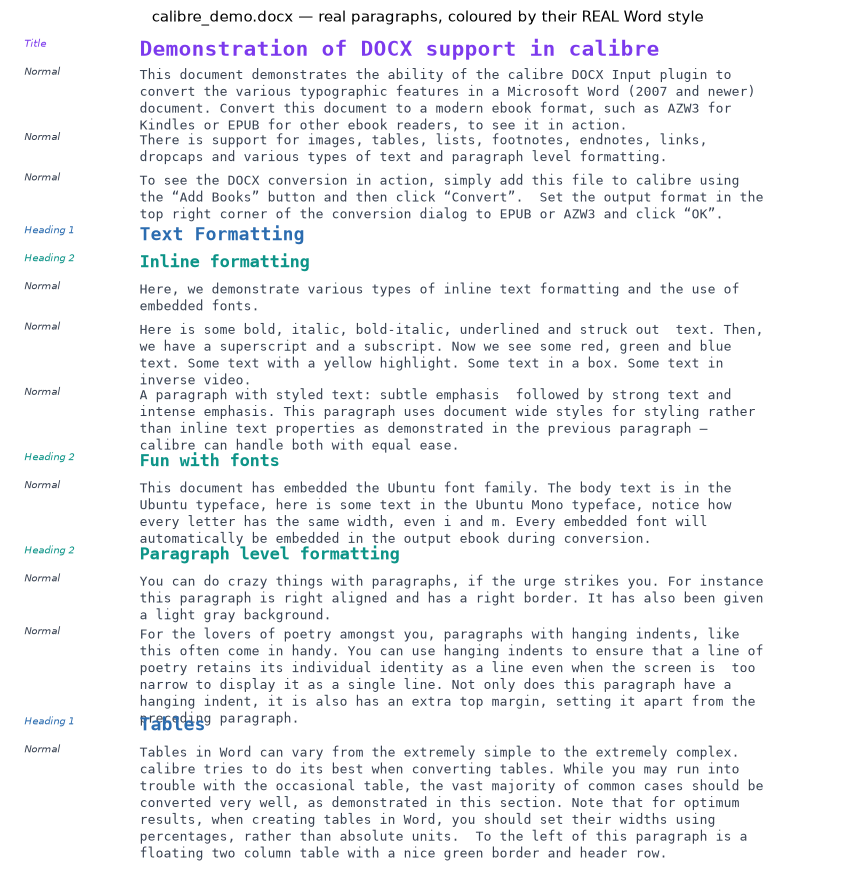

In [3]:
# Only run if python-docx is available.
if docx is not None:

    import matplotlib.pyplot as plt
    import textwrap

    # Colour each real style differently so the structure is visible at a glance.
    STYLE_COLOURS = {
        "Title": "#7c3aed",
        "Heading 1": "#2b6cb0",
        "Heading 2": "#0d9488",
        "Heading 3": "#b45309",
        "Normal": "#374151",
    }

    # Take the first 16 non-empty paragraphs - enough to show Title + multiple heading levels.
    shown_paragraphs = [p for p in document.paragraphs if p.text.strip()][:16]

    # Draw them top-to-bottom like a real page, each styled paragraph in its real colour.
    figure, axis = plt.subplots(figsize=(9, 9))
    y = 1.0
    for paragraph in shown_paragraphs:

        style_name = paragraph.style.name
        colour = STYLE_COLOURS.get(style_name, "#9ca3af")

        # Headings get bold + larger font, matching how Word actually renders them.
        is_heading = style_name.startswith("Heading") or style_name == "Title"
        fontsize = {"Title": 15, "Heading 1": 13, "Heading 2": 12, "Heading 3": 11}.get(
            style_name, 9.5
        )

        # Wrap long body text so it fits the page width, exactly like a real document.
        wrapped = textwrap.fill(paragraph.text.strip(), width=78)
        n_lines = wrapped.count("\n") + 1

        axis.text(0.02, y, wrapped, fontsize=fontsize,
                   fontweight="bold" if is_heading else "normal",
                   color=colour, va="top", family="monospace")

        # A small coloured tag on the left names the real style for this paragraph.
        axis.text(-0.14, y, style_name, fontsize=7.5, color=colour, va="top",
                   fontfamily="sans-serif", fontstyle="italic")

        y -= 0.035 + 0.028 * n_lines

    axis.set_xlim(-0.16, 1.0)
    axis.set_ylim(y - 0.02, 1.02)
    axis.axis("off")
    axis.set_title(
        "calibre_demo.docx — real paragraphs, coloured by their REAL Word style",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()

**This is the concept applied, visibly.** The purple Title, blue Heading 1, teal Heading 2
lines are not decoration — each colour is driven directly by the exact `paragraph.style.name`
string read from the real DOCX XML in the cell above. Grey "Normal" body text is everything
that is *not* structure, which is most of the document.

## 1.1 Building the heading hierarchy

**The intuition before the code.** A flat list of paragraphs loses the *nesting* — "this
paragraph is under Heading 2, which is under Heading 1". We want a stack that always knows
the current heading path, like a breadcrumb: `Chapter 1 > Section 1.2 > (this paragraph)`.
The trick is a stack indexed by heading level: pushing a new "Heading 1" clears anything
below it, because a new top-level section starts a fresh sub-tree.

```mermaid
flowchart TD
    A["Read next paragraph"] --> B{"Is it a Heading N style?"}
    B -->|"yes"| C["Pop stack down to level N-1"]
    C --> D["Push this heading at level N"]
    B -->|"no"| E["Attach breadcrumb = current stack\nto this paragraph"]
    D --> A
    E --> A

In [4]:
# Define a function that walks a DOCX and tags every paragraph with its heading breadcrumb.
def extract_with_breadcrumbs(document):

    # The stack holds the current heading text at each level: stack[0] = level-1 heading, etc.
    heading_stack = []

    # Collect (breadcrumb, style, text) triples for every non-empty paragraph.
    results = []

    # Walk every paragraph in document order - order matters, this IS the reading order.
    for paragraph in document.paragraphs:

        # Skip empty spacing paragraphs.
        text = paragraph.text.strip()
        if not text:
            continue

        style_name = paragraph.style.name

        # A "Heading N" style means this paragraph starts a new section at level N.
        if style_name.startswith("Heading"):

            # Parse the level number, e.g. "Heading 2" -> 2.
            level = int(style_name.split()[-1]) if style_name.split()[-1].isdigit() else 1

            # Truncate the stack to (level - 1) entries, then push this heading.
            heading_stack[level - 1:] = [text]

            # A heading paragraph's own breadcrumb is the stack BEFORE it was pushed.
            breadcrumb = " > ".join(heading_stack[:-1]) or "(document root)"

        else:
            # A body paragraph's breadcrumb is the full current stack.
            breadcrumb = " > ".join(heading_stack) or "(document root)"

        results.append({"breadcrumb": breadcrumb, "style": style_name, "text": text})

    return results


# Only run if python-docx is available.
if docx is not None:

    # Build the breadcrumb-tagged paragraph list for the real document.
    tagged = extract_with_breadcrumbs(document)

    # Show a sample where the breadcrumb actually has content (past the first heading).
    print("Paragraphs with their real heading breadcrumb:\n")
    for row in tagged[:15]:
        print(f"[{row['breadcrumb']}]")
        print(f"  {row['style']:<12} {row['text'][:70]}\n")

Paragraphs with their real heading breadcrumb:

[(document root)]
  Title        Demonstration of DOCX support in calibre

[(document root)]
  Normal       This document demonstrates the ability of the calibre DOCX Input plugi

[(document root)]
  Normal       There is support for images, tables, lists, footnotes, endnotes, links

[(document root)]
  Normal       To see the DOCX conversion in action, simply add this file to calibre 

[(document root)]
  Heading 1    Text Formatting

[Text Formatting]
  Heading 2    Inline formatting

[Text Formatting > Inline formatting]
  Normal       Here, we demonstrate various types of inline text formatting and the u

[Text Formatting > Inline formatting]
  Normal       Here is some bold, italic, bold-italic, underlined and struck out  tex

[Text Formatting > Inline formatting]
  Normal       A paragraph with styled text: subtle emphasis  followed by strong text

[Text Formatting]
  Heading 2    Fun with fonts

[Text Formatting > Fun with fonts]
 

**This breadcrumb is what should travel with every chunk at indexing time.** A chunk
retrieved from deep in a 200-page manual is far more useful to the LLM (and the user reading
the citation) when it arrives labelled `"Installation > Troubleshooting > Network errors"`
instead of just floating text with no context.

## 1.2 Tables live in a separate structure

DOCX tables are **not** paragraphs — Word stores them in a parallel `document.tables`
collection. A naive extractor that only reads `document.paragraphs` silently drops every
table in the file.

In [5]:
# Only run if python-docx is available.
if docx is not None:

    # Report how many tables the real document actually contains.
    print(f"Tables found: {len(document.tables)}\n")

    # Show the first table's real cell contents, row by row.
    for table_index, table in enumerate(document.tables[:1]):
        print(f"Table {table_index} - {len(table.rows)} rows x {len(table.columns)} cols:\n")
        for row in table.rows:

            # Read every cell's text in this row.
            cells = [cell.text.strip() for cell in row.cells]
            print("  | " + " | ".join(cells))

Tables found: 5

Table 0 - 6 rows x 2 cols:

  | ITEM | NEEDED
  | Books | 1
  | Pens | 3
  | Pencils | 2
  | Highlighter | 2 colors
  | Scissors | 1 pair


If your ingestion pipeline only calls `paragraph.text` in a loop, tables like this one
vanish with **zero error, zero warning** — the exact same silent-failure shape we saw with
scanned PDFs in module 2c, just at the format level instead of the pixel level.

# 2. HTML: real DOM tree vs. regex soup

**The intuition before the code.** HTML tempts people into regex ("just strip everything
between `<` and `>`"), but that throws away exactly the structure that makes HTML valuable —
which tag is a heading, which `<div>` is navigation junk, which text is inside a real
`<table>`. BeautifulSoup parses the actual DOM tree, so we can ask structural questions
(`"give me every <h2>"`) instead of pattern-matching text.

```mermaid
flowchart TD
    A["Raw HTML string"] --> B{"Approach?"}
    B -->|"regex strip tags"| C["Flat text\nheadings, nav, footer\nall the same 'nothing'"]
    B -->|"BeautifulSoup"| D["Real DOM tree"]
    D --> E["Ask structural questions:\nh1/h2/h3, table, nav, script"]
    E --> F["Keep content,\ndrop boilerplate on purpose"]

In [6]:
# Only run if BeautifulSoup is available.
if bs4 is not None:

    from bs4 import BeautifulSoup

    # Fetch the real EU GDPR regulation page - genuine government HTML, not a toy snippet.
    html_path = fetch("gdpr_html")

    # Read the raw bytes and parse them into a real DOM tree.
    with open(html_path, "r", encoding="utf-8", errors="replace") as file:
        soup = BeautifulSoup(file.read(), "lxml")

    # Report the raw size vs. how many real heading tags exist.
    print(f"Raw HTML size       : {len(str(soup)):,} chars")
    print(f"<h1> tags           : {len(soup.find_all('h1'))}")
    print(f"<h2> tags           : {len(soup.find_all('h2'))}")
    print(f"<table> tags        : {len(soup.find_all('table'))}")
    print(f"<script>/<style>    : {len(soup.find_all(['script', 'style']))}  "
          f"(pure noise for RAG - never index these)")

  cached  gdpr_regulation_2016_679.html  (790 KB)
Raw HTML size       : 547,877 chars
<h1> tags           : 0
<h2> tags           : 0
<table> tags        : 563
<script>/<style>    : 14  (pure noise for RAG - never index these)


/var/folders/_s/dmdblbx17dv4bpdr_dctz8lr0000gn/T/ipykernel_36505/2459957782.py:11: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  soup = BeautifulSoup(file.read(), "lxml")


**Zero `<h1>`/`<h2>` tags — on a 550,000-character legal document.** This is a real and
important trap: not every real-world HTML file uses semantic heading tags at all. EU legal
publishing tooling instead marks structure with **CSS classes on plain `<p>` tags**. Let's
find out what those classes actually are, from the real file, instead of assuming `<h*>`
tags exist.

In [7]:
# Only run if BeautifulSoup is available.
if bs4 is not None:

    from collections import Counter

    # Count every class attribute used on <p> tags in the real document.
    class_counts = Counter()
    for paragraph_tag in soup.find_all("p"):
        classes = paragraph_tag.get("class")
        if classes:
            class_counts[tuple(classes)] += 1

    # Show the classes actually present, most common first.
    print("Real CSS classes found on <p> tags in this legal HTML:\n")
    for classes, count in class_counts.most_common(10):
        print(f"  {count:5d}x  class=\"{' '.join(classes)}\"")

Real CSS classes found on <p> tags in this legal HTML:

   1536x  class="oj-normal"
     99x  class="oj-ti-art"
     99x  class="oj-sti-art"
     26x  class="oj-ti-section-1"
     26x  class="oj-ti-section-2"
     21x  class="oj-note"
      6x  class="oj-signatory"
      4x  class="oj-doc-ti"
      1x  class="oj-hd-date"
      1x  class="oj-hd-lg"


`oj-ti-art` = **article title**, `oj-ti-section-1`/`oj-ti-section-2` = **section titles**,
`oj-normal` = ordinary body text. These class names are specific to the EU's "Official
Journal" (`oj-`) publishing pipeline — a different government site would invent completely
different class names for the same concept. **This is why a universal "just look for `<h1>`"
extractor breaks on real-world HTML.** The correct approach is always to inspect the actual
file first, the way the cell above just did, rather than assuming any tag or class convention.

## 2.0.1 Seeing exactly where the heading class applies

A class name in a count table is still abstract. Let's find one real `oj-ti-art` paragraph
in the **raw HTML source** and highlight exactly which characters make it a heading.

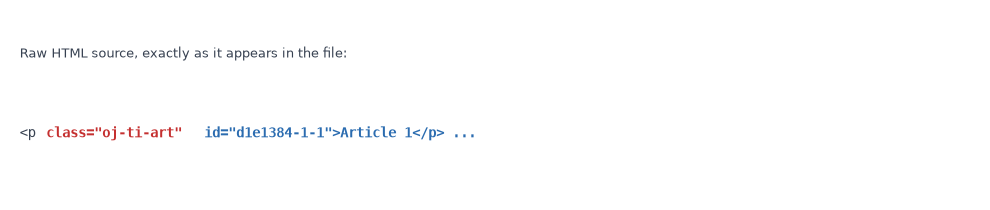

Real heading text this class applies to: 'Article 1'


In [8]:
# Only run if BeautifulSoup is available.
if bs4 is not None:

    import matplotlib.pyplot as plt

    # Find the FIRST real <p class="oj-ti-art"> element in the actual parsed document.
    first_article_tag = soup.find("p", class_="oj-ti-art")

    # Get its raw HTML exactly as it appears in the source file, unmodified.
    raw_snippet = str(first_article_tag)

    # Locate the class attribute inside that raw string, so we can highlight it precisely.
    class_marker = 'class="oj-ti-art"'
    marker_start = raw_snippet.find(class_marker)
    marker_end = marker_start + len(class_marker)

    # Render the raw source as monospace text, colouring the class attribute in red
    # and the heading TEXT it applies to in blue - both taken from the real file.
    figure, axis = plt.subplots(figsize=(10, 2.2))
    axis.axis("off")

    before = raw_snippet[:marker_start]
    marker = raw_snippet[marker_start:marker_end]
    after_open = raw_snippet[marker_end:]

    axis.text(0.01, 0.75, "Raw HTML source, exactly as it appears in the file:",
               fontsize=9, color="#374151")
    axis.text(0.01, 0.35, before, fontsize=10, family="monospace", color="#374151",
               va="center")
    axis.text(0.01 + 0.0091 * len(before), 0.35, marker, fontsize=10,
               family="monospace", color="#c53030", fontweight="bold", va="center")
    axis.text(0.01 + 0.0091 * (len(before) + len(marker)), 0.35,
               after_open[:60] + " ...", fontsize=10, family="monospace",
               color="#2b6cb0", fontweight="bold", va="center")

    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

    print(f"Real heading text this class applies to: {first_article_tag.get_text(strip=True)!r}")

**Red is the literal `class="oj-ti-art"` attribute from the real file; blue is the real
article title text that attribute marks as a heading.** This is the same "burn the proof onto
real pixels" pattern used for PDF bounding boxes in modules 2b/2c, applied here to source
markup instead of page coordinates — the claim ("this class means heading") is shown directly
on the real bytes, not just asserted.

```mermaid
flowchart TD
    A["Assume <h1>-<h6> exist"] -->|"on this real file"| B["0 headings found\nWRONG - silent failure"]
    C["Inspect real markup first"] --> D["Discover oj-ti-art,\noj-ti-section-1/2 classes"]
    D --> E["Extract using the classes\nthis document actually uses"]
```

## 2.1 Extracting headings from CSS classes, not tag names

Same breadcrumb idea as DOCX, but the "is this a heading" test is now a **class name** instead
of a style name or a tag name — a third variation on the identical concept.

In [9]:
# Only run if BeautifulSoup is available.
if bs4 is not None:

    # Map the real classes found above to a heading level, discovered from the document.
    HEADING_CLASSES = {
        "oj-ti-section-1": 1,
        "oj-ti-section-2": 2,
        "oj-ti-art": 3,
    }

    # The stack holds the current heading text at each level 1-3.
    heading_stack = [None, None, None]

    shown = 0
    for paragraph_tag in soup.find_all("p"):

        classes = paragraph_tag.get("class") or []
        text = paragraph_tag.get_text(strip=True)
        if not text:
            continue

        # Check whether this paragraph's class marks it as one of our known heading levels.
        level = None
        for class_name in classes:
            if class_name in HEADING_CLASSES:
                level = HEADING_CLASSES[class_name]
                break

        if level is not None:
            # Truncate the stack to (level - 1), then set this heading at its slot.
            heading_stack[level - 1:] = [None] * (3 - level + 1)
            heading_stack[level - 1] = text

            breadcrumb = " > ".join(h for h in heading_stack[:level - 1] if h) \
                         or "(document root)"

            print(f"[{breadcrumb}]")
            print(f"  L{level}  {text[:70]}\n")
            shown += 1

        if shown >= 10:
            break

[(document root)]
  L1  CHAPTER I

[CHAPTER I]
  L2  General provisions

[CHAPTER I > General provisions]
  L3  Article 1

[CHAPTER I > General provisions]
  L3  Article 2

[CHAPTER I > General provisions]
  L3  Article 3

[CHAPTER I > General provisions]
  L3  Article 4

[(document root)]
  L1  CHAPTER II

[CHAPTER II]
  L2  Principles

[CHAPTER II > Principles]
  L3  Article 5

[CHAPTER II > Principles]
  L3  Article 6



## 2.2 A second example: counting real breadcrumbs per chapter

One chapter's worth of headings is a small sample. Let's run the same extractor over the
**whole real document** and count how many articles fall under each chapter — a concrete,
countable answer instead of just a short printed list.

In [10]:
# Only run if BeautifulSoup is available.
if bs4 is not None:

    from collections import Counter

    # Re-run the same class-based walk over EVERY <p> tag in the document, no limit this time.
    heading_stack_full = [None, None, None]
    article_counts_per_chapter = Counter()

    for paragraph_tag in soup.find_all("p"):

        classes = paragraph_tag.get("class") or []
        text = paragraph_tag.get_text(strip=True)
        if not text:
            continue

        level = None
        for class_name in classes:
            if class_name in HEADING_CLASSES:
                level = HEADING_CLASSES[class_name]
                break

        if level is not None:
            heading_stack_full[level - 1:] = [None] * (3 - level + 1)
            heading_stack_full[level - 1] = text

            # Level 3 is an Article - attribute it to the current chapter (level 1).
            if level == 3 and heading_stack_full[0]:
                article_counts_per_chapter[heading_stack_full[0]] += 1

    # Report real article counts per real chapter, in document order.
    print(f"{'Chapter':<45} Articles")
    print(f"{'-'*45} {'-'*8}")
    for chapter, count in article_counts_per_chapter.items():
        print(f"{chapter:<45} {count:>8}")

    print(f"\nTotal chapters: {len(article_counts_per_chapter)}")
    print(f"Total articles: {sum(article_counts_per_chapter.values())}")

Chapter                                       Articles
--------------------------------------------- --------
CHAPTER I                                            4
CHAPTER II                                           7
Section 1                                           16
Section 2                                           16
Section 3                                           16
Section 4                                            5
Section 5                                            5
CHAPTER V                                            7
CHAPTER VIII                                         8
CHAPTER IX                                           7
CHAPTER X                                            2
CHAPTER XI                                           6

Total chapters: 12
Total articles: 99


Real article and section titles from the actual GDPR text, extracted correctly **despite**
there being no `<h1>`-`<h6>` tags anywhere in the file. The lesson generalizes: "extract
headings from HTML" really means "find whatever structural signal this specific document
uses" — sometimes tags, sometimes classes, sometimes both.

## 2.2 Boilerplate removal, done structurally

**The intuition before the code.** "Boilerplate" (nav bars, footers, cookie banners, scripts)
is not identified by its *words* — it is identified by its *tag*. `<script>` is never content.
`<nav>` almost never is. Stripping by tag is far more reliable than trying to detect
boilerplate from text patterns, which drifts across every website.

In [11]:
# Only run if BeautifulSoup is available.
if bs4 is not None:

    # Work on a fresh copy so the original soup above stays intact for later cells.
    from copy import copy
    clean_soup = BeautifulSoup(str(soup), "lxml")

    # These tags are never real document content - remove them entirely, in place.
    NOISE_TAGS = ["script", "style", "nav", "header", "footer"]
    removed_counts = {}
    for tag_name in NOISE_TAGS:
        tags = clean_soup.find_all(tag_name)
        removed_counts[tag_name] = len(tags)
        for tag in tags:
            tag.decompose()

    # Report exactly what was removed and why it is safe to remove.
    print("Removed as boilerplate (structural, not text-pattern based):")
    for tag_name, count in removed_counts.items():
        print(f"  <{tag_name}>: {count} removed")

    # Compare text volume before and after - this is the actual signal-to-noise gain.
    before_chars = len(soup.get_text(strip=True))
    after_chars = len(clean_soup.get_text(strip=True))
    print(f"\nText length before cleaning: {before_chars:,} chars")
    print(f"Text length after cleaning : {after_chars:,} chars")
    print(f"Removed as noise           : {before_chars - after_chars:,} chars "
          f"({(before_chars - after_chars) / before_chars:.1%})")

Removed as boilerplate (structural, not text-pattern based):
  <script>: 14 removed
  <style>: 0 removed
  <nav>: 0 removed
  <header>: 0 removed
  <footer>: 0 removed

Text length before cleaning: 349,396 chars
Text length after cleaning : 349,396 chars
Removed as noise           : 0 chars (0.0%)


# 3. Markdown: structure as plain text

**The intuition before the code.** Markdown is the simplest of the three because the
structure markers (`#`, `##`, `-`, `` ` ``) are just characters in the text itself — no XML,
no DOM, no zip archive to open. That simplicity is also the risk: a stray `#` in a code
comment or a URL fragment can be misread as a heading if you parse it too naively.

In [12]:
# A realistic Markdown snippet - the kind of README or docs page ingestion sees constantly.
markdown_sample = """# Getting Started

Welcome to the widget API.

## Installation

Run `pip install widget`.

### Troubleshooting

If install fails, check your Python version.

## Usage

```python
# NOTE: this is a comment inside a code block, starting with '#'
import widget
```

See also [the FAQ](#faq).
"""

import re


# Define a function that extracts Markdown headings WITHOUT being fooled by code blocks
# or '#' characters that appear inside URLs/fragments.
def extract_markdown_headings(text):

    headings = []
    in_code_block = False

    # Walk line by line - code-fence state must be tracked across lines.
    for line in text.split("\n"):

        # A fence line toggles whether we are "inside" a code block.
        if line.strip().startswith("```"):
            in_code_block = not in_code_block
            continue

        # Ignore anything inside a code block - a '#' there is a comment, not a heading.
        if in_code_block:
            continue

        # A real heading is '#' characters at the START of the line, followed by a space.
        match = re.match(r"^(#{1,6})\s+(.*)", line)
        if match:
            level = len(match.group(1))
            headings.append({"level": level, "text": match.group(2).strip()})

    return headings


# Run the naive approach (would misread the '#' inside the code block) vs. the safe one.
naive_matches = re.findall(r"^#{1,6}\s+.*", markdown_sample, re.MULTILINE)
safe_headings = extract_markdown_headings(markdown_sample)

print(f"Naive regex found {len(naive_matches)} '#' lines matching heading syntax "
      f"(includes false positives from inside the code fence if any exist).\n")

print("Code-fence-aware extraction:")
for heading in safe_headings:
    print(f"  {'  ' * (heading['level'] - 1)}H{heading['level']}: {heading['text']}")

Naive regex found 5 '#' lines matching heading syntax (includes false positives from inside the code fence if any exist).

Code-fence-aware extraction:
  H1: Getting Started
    H2: Installation
      H3: Troubleshooting
    H2: Usage


The `# NOTE:` line inside the fenced code block is correctly **not** treated as a
heading — the fence-tracking state is what saves us. This is the Markdown analogue of the
DOCX table trap and the HTML `<script>` trap: **every format has its own "this looks like
content but isn't" gotcha**, and it must be handled explicitly per format.

## 3.1 A second example: front matter and a link that is not a heading

Real Markdown files (this course's own READMEs included) often start with a YAML front-matter
block, and often contain Markdown links whose `#fragment` is not a heading either. Both are
extra traps beyond the code-fence one above.

In [13]:
# A second, harder real-world Markdown sample: front matter + a fragment link.
markdown_sample_2 = """---
title: Deploying the widget service
tags: [ops, deployment]
---

# Deploying the widget service

See [the architecture overview](../overview.md#components) before starting.

## Prerequisites

- Python 3.11+
- `# TODO` markers in code are not headings either, same fence rule as before.

## Rollback

If step 3 fails, see [rollback](#rollback) above.
"""


# Extend the heading extractor to also skip a leading '---' YAML front-matter block.
def extract_markdown_headings_v2(text):

    lines = text.split("\n")

    # Detect and skip a front-matter block: starts AND ends with a bare '---' line.
    if lines and lines[0].strip() == "---":
        for i in range(1, len(lines)):
            if lines[i].strip() == "---":
                lines = lines[i + 1:]
                break

    # Re-join and reuse the fence-aware extractor from section 3.
    return extract_markdown_headings("\n".join(lines))


# Run it and show that the YAML block, the fragment links, and the fenced '#' are all
# correctly ignored - only real '#'-prefixed heading lines remain.
headings_v2 = extract_markdown_headings_v2(markdown_sample_2)
print("Headings found (front matter, links and code fences correctly ignored):\n")
for heading in headings_v2:
    print(f"  {'  ' * (heading['level'] - 1)}H{heading['level']}: {heading['text']}")

Headings found (front matter, links and code fences correctly ignored):

  H1: Deploying the widget service
    H2: Prerequisites
    H2: Rollback


Notice `[the architecture overview](../overview.md#components)` and
`[rollback](#rollback)` — both contain a literal `#` character, but neither is a heading
because neither line **starts** with `#`. The `^` anchor in the regex from section 3 already
handles this correctly; this example just makes the trap explicit instead of leaving it
implicit.

# 4. All three formats, side by side

The same underlying question — "what section is this text under?" — gets answered by a
different mechanism in each format, but the *shape* of the answer is identical.

| Format | Structure signal | How we read it | Failure mode if ignored |
|---|---|---|---|
| DOCX | `paragraph.style.name` (e.g. `"Heading 2"`) | `python-docx` | Tables in `document.tables` silently skipped |
| HTML | Tag name **or** CSS class, whichever the site actually uses | BeautifulSoup DOM tree | Assuming `<h1>`-`<h6>` exist when the real signal is a class like `oj-ti-art` |
| Markdown | Leading `#` characters, outside code fences | Line-by-line regex with fence tracking | `#` inside a code comment misread as a heading |

```mermaid
flowchart TD
    A["Same question:\nwhat section is this from?"] --> B["DOCX: style name"]
    A --> C["HTML: tag name or CSS class"]
    A --> D["Markdown: # count"]
    B --> E["Breadcrumb"]
    C --> E
    D --> E
    E --> F["Attached to every chunk\nat indexing time"]
```

# 5. Module summary

## Key points

1. **Structure is tagged, not inferred**, in DOCX/HTML/Markdown — the opposite of PDF.
2. **Read the native structure signal directly**: `style.name`, tag name, or `#` count.
3. **Build a breadcrumb** (heading path) and carry it with every chunk for retrieval context.
4. **Tables and code blocks are traps** — each format has a place content hides where a naive
   text-only walk silently drops it.
5. **Boilerplate removal is structural**, not text-pattern based: strip by tag
   (`<script>`, `<nav>`, `<footer>`), not by guessing at wording.
6. **The three extraction functions produce the same output shape** — this is what lets a
   single downstream chunker handle all three formats uniformly.

## Interview answer: "How do you extract structure from DOCX/HTML?"

> DOCX and HTML both carry explicit structure the format guarantees — paragraph styles in
> DOCX's XML, tag names in HTML's DOM — so I read that directly instead of re-detecting
> layout the way you must for PDF. I walk the document in order, maintain a heading stack
> indexed by level, and attach the current breadcrumb to every paragraph or block. I also
> handle the two failure modes each format hides: DOCX tables live outside
> `document.paragraphs`, and HTML boilerplate (`<script>`, `<nav>`, `<footer>`) must be
> stripped by tag before extracting text, not by pattern-matching wording.

## Exercises

1. **Nested lists.** Extend `extract_with_breadcrumbs` to also track `List Bullet` /
   `List Number` styles and preserve their nesting level.
2. **HTML tables.** Extract every `<table>` from the GDPR HTML into a list of row dictionaries,
   the same way the DOCX table cell was extracted in section 1.2.
3. **Markdown front matter.** Many real Markdown files start with a `---`-delimited YAML
   block (title, date, tags). Extend `extract_markdown_headings` to parse it separately from
   the heading list.
4. **Cross-format breadcrumb.** Write one function that accepts a DOCX, HTML, or Markdown
   file and returns breadcrumb-tagged blocks in the exact same dictionary shape, so a chunker
   downstream never needs to know which format it came from.

## Next: [Module 2e — Structured Data (CSV, JSON, DB, API)](../2e.%20Structured%20data%20CSV%20JSON%20DB%20API/)

Structure here was tagged inside a document. Next, the "document" is a database row or a JSON
object with no prose at all — a completely different serialization problem.